# Trace Overlay: grizli Image + Optical Model & aXe Traces

Overlay both the roman_disperser optical model trace and the grizli/aXe trace
on the grizli MODEL image for visual comparison of trace positions.

- **Image:** grizli MODEL HDU (electrons/s)
- **Cyan line:** roman_disperser optical model trace
- **Red line:** grizli/aXe trace (from `TestBuild_rot_det1.conf`)
- **Scale:** Linear

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

# Local grism_dispersion module (aXeConf)
sys.path.insert(0, str(Path('.').resolve()))
import grism_dispersion

from roman_disperser.optical_model import RomanOpticalModel

plt.rcParams['font.size'] = 11

In [2]:
# Configuration
SCA = 1
ORDER = '1'
ROTATION_CENTER = 2044

STARS = {
    'center': (2043.0, 2043.0),
    'BL': (100.0, 100.0),
    'TL': (100.0, 3900.0),
    'BR': (3900.0, 100.0),
    'TR': (3900.0, 3900.0),
}

# aXe pixel offset range (matching Keith's notebook)
DX_AXE = np.flip(np.arange(-380, 624, 1))  # 623 down to -380

# Paths
project_root = Path(os.environ.get('PIXI_PROJECT_ROOT', '.'))
config_path = project_root / 'data' / 'Roman_grism_OpticalModel_v0.8.yaml'
sens_path = project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024.fits'
conf_path = Path('.') / 'TestBuild_rot_det1.conf'
grizli_file = Path('.') / 'data' / 'grism_ra10_dec0_pa60_detSCA01.fits'

In [3]:
# Load grizli MODEL image
with fits.open(grizli_file) as hdul:
    grizli_model = hdul['MODEL'].data.astype(np.float32)

print(f'Grizli MODEL: {grizli_model.shape}, '
      f'max = {grizli_model.max():.4e} e/s, '
      f'nonzero = {(grizli_model > 0).sum()}')

# Load sensitivity to determine wavelength range
sens_table = Table.read(sens_path)
sens_wl_ang = np.array(sens_table['WAVELENGTH'])
sens_val = np.array(sens_table['SENSITIVITY'])
mask_pos = sens_val > 0
wl_min_um = sens_wl_ang[mask_pos].min() / 1e4
wl_max_um = sens_wl_ang[mask_pos].max() / 1e4
print(f'Sensitivity > 0: {wl_min_um:.4f} \u2013 {wl_max_um:.4f} \u03bcm')

# Load aXe config
grizli_conf = grism_dispersion.aXeConf(conf_file=str(conf_path))

# Load optical model
model = RomanOpticalModel(config_file=str(config_path))
# Fine wavelength grid for smooth trace lines
model.wl_grid = np.linspace(wl_min_um, wl_max_um, 500)
print(f'Optical model loaded, trace grid: {len(model.wl_grid)} wavelengths')

Grizli MODEL: (4088, 4088), max = 1.8022e+07 e/s, nonzero = 1481518
Sensitivity > 0: 0.9930 – 1.9530 μm
Optical model loaded, trace grid: 500 wavelengths


In [4]:
def rotate_90(xc, yc, center=ROTATION_CENTER):
    """Rotate by 90 deg CCW about (center, center), int() truncation."""
    theta = np.pi / 2
    x_rot = int(np.cos(theta) * (xc - center) - np.sin(theta) * (yc - center) + center)
    y_rot = int(np.sin(theta) * (xc - center) + np.cos(theta) * (yc - center) + center)
    return x_rot, y_rot


# Compute both traces for all stars
traces = {}

for label, (xc, yc) in STARS.items():
    # --- aXe/grizli trace ---
    x_rot, y_rot = rotate_90(xc, yc)
    dy_axe, lam_axe_ang = grizli_conf.get_beam_trace(x=x_rot, y=y_rot, dx=DX_AXE, beam='A')
    axe_x = xc + dy_axe
    axe_y = yc - DX_AXE
    axe_lam_um = lam_axe_ang / 1e4

    # Filter to sensitivity > 0 range
    in_sens = (axe_lam_um >= wl_min_um) & (axe_lam_um <= wl_max_um)
    axe_x = axe_x[in_sens]
    axe_y = axe_y[in_sens]
    axe_lam_um = axe_lam_um[in_sens]

    # --- Optical model trace ---
    xfpa, yfpa = model.coords.convert_sca_to_fpa(xc, yc, sca=SCA)
    trace = model._get_beam_trace(xfpa, yfpa, sca=SCA, width=1, order=ORDER)
    om_x = trace['trace_sca_x'].ravel()
    om_y = trace['trace_sca_y'].ravel()

    traces[label] = {
        'xc': xc, 'yc': yc,
        'axe_x': axe_x, 'axe_y': axe_y,
        'om_x': om_x, 'om_y': om_y,
    }
    print(f'{label:>8s}: om y=[{om_y.min():.0f}, {om_y.max():.0f}], '
          f'axe y=[{axe_y.min():.0f}, {axe_y.max():.0f}]')

  center: om y=[1499, 2377], axe y=[1501, 2374]
      BL: om y=[-454, 435], axe y=[-452, 432]
      TL: om y=[3355, 4224], axe y=[3356, 4221]
      BR: om y=[-467, 423], axe y=[-465, 420]
      TR: om y=[3344, 4215], axe y=[3346, 4212]


---
## Full Detector View

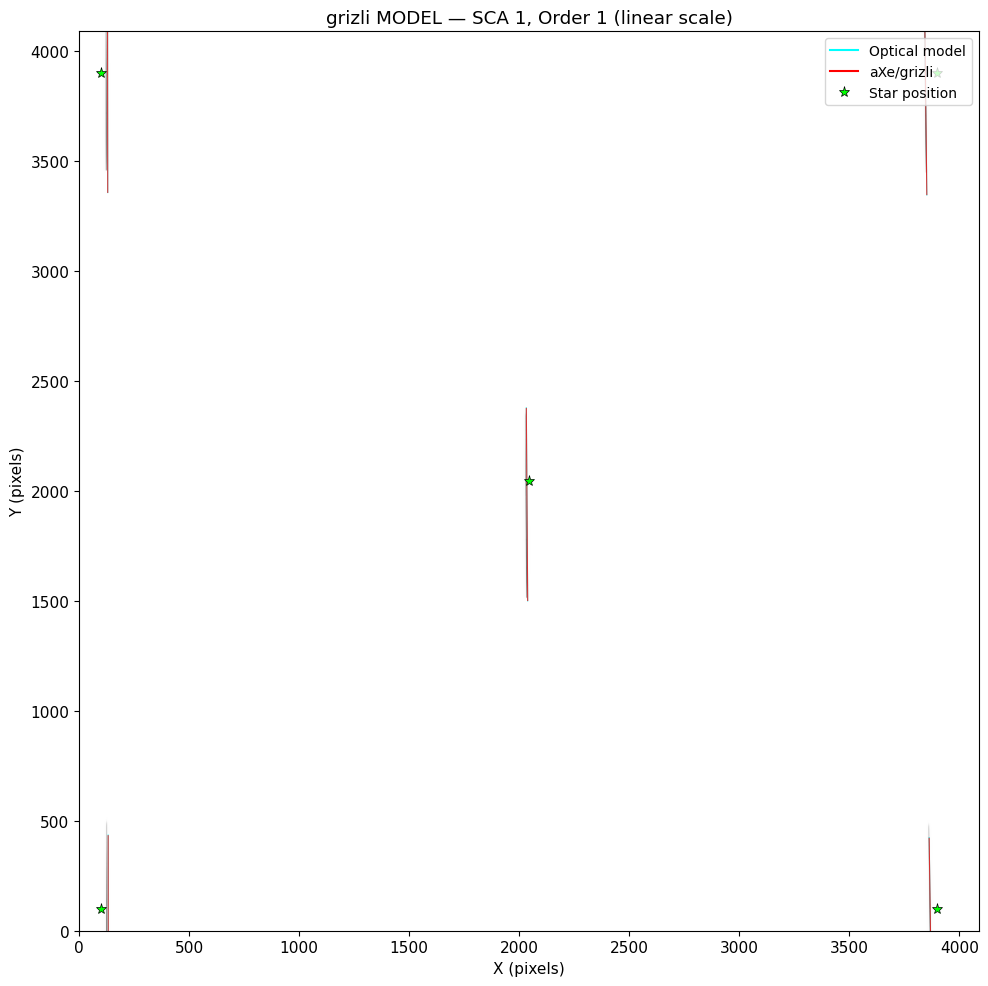

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

# Linear scale, clip at 99.9th percentile of nonzero pixels for visibility
nonzero = grizli_model[grizli_model > 0]
vmax = np.percentile(nonzero, 99.9)

# imshow with origin='lower' uses 0-indexed array coords.
# Our traces are in 1-indexed FITS coords. The offset is ~1 pixel;
# we accept this and don't correct (as discussed).
ax.imshow(grizli_model, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)

for label, tr in traces.items():
    ax.plot(tr['om_x'], tr['om_y'], '-', color='cyan', lw=0.8, alpha=0.8)
    ax.plot(tr['axe_x'], tr['axe_y'], '-', color='red', lw=0.8, alpha=0.8)
    ax.plot(tr['xc'], tr['yc'], '*', color='lime', ms=8, mew=0.5, mec='k')

# Legend (plot invisible lines for legend entries)
ax.plot([], [], '-', color='cyan', lw=1.5, label='Optical model')
ax.plot([], [], '-', color='red', lw=1.5, label='aXe/grizli')
ax.plot([], [], '*', color='lime', ms=8, mew=0.5, mec='k', label='Star position')
ax.legend(loc='upper right', fontsize=10)

ax.set_xlim(0, 4088)
ax.set_ylim(0, 4088)
ax.set_title(f'grizli MODEL \u2014 SCA {SCA}, Order {ORDER} (linear scale)')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
plt.tight_layout()
plt.show()

---
## Zoomed Views: Each Star

1200 pixels in y, with tailored x-ranges per position:
center [2000, 2050], left [90, 150], right [3825, 3910].

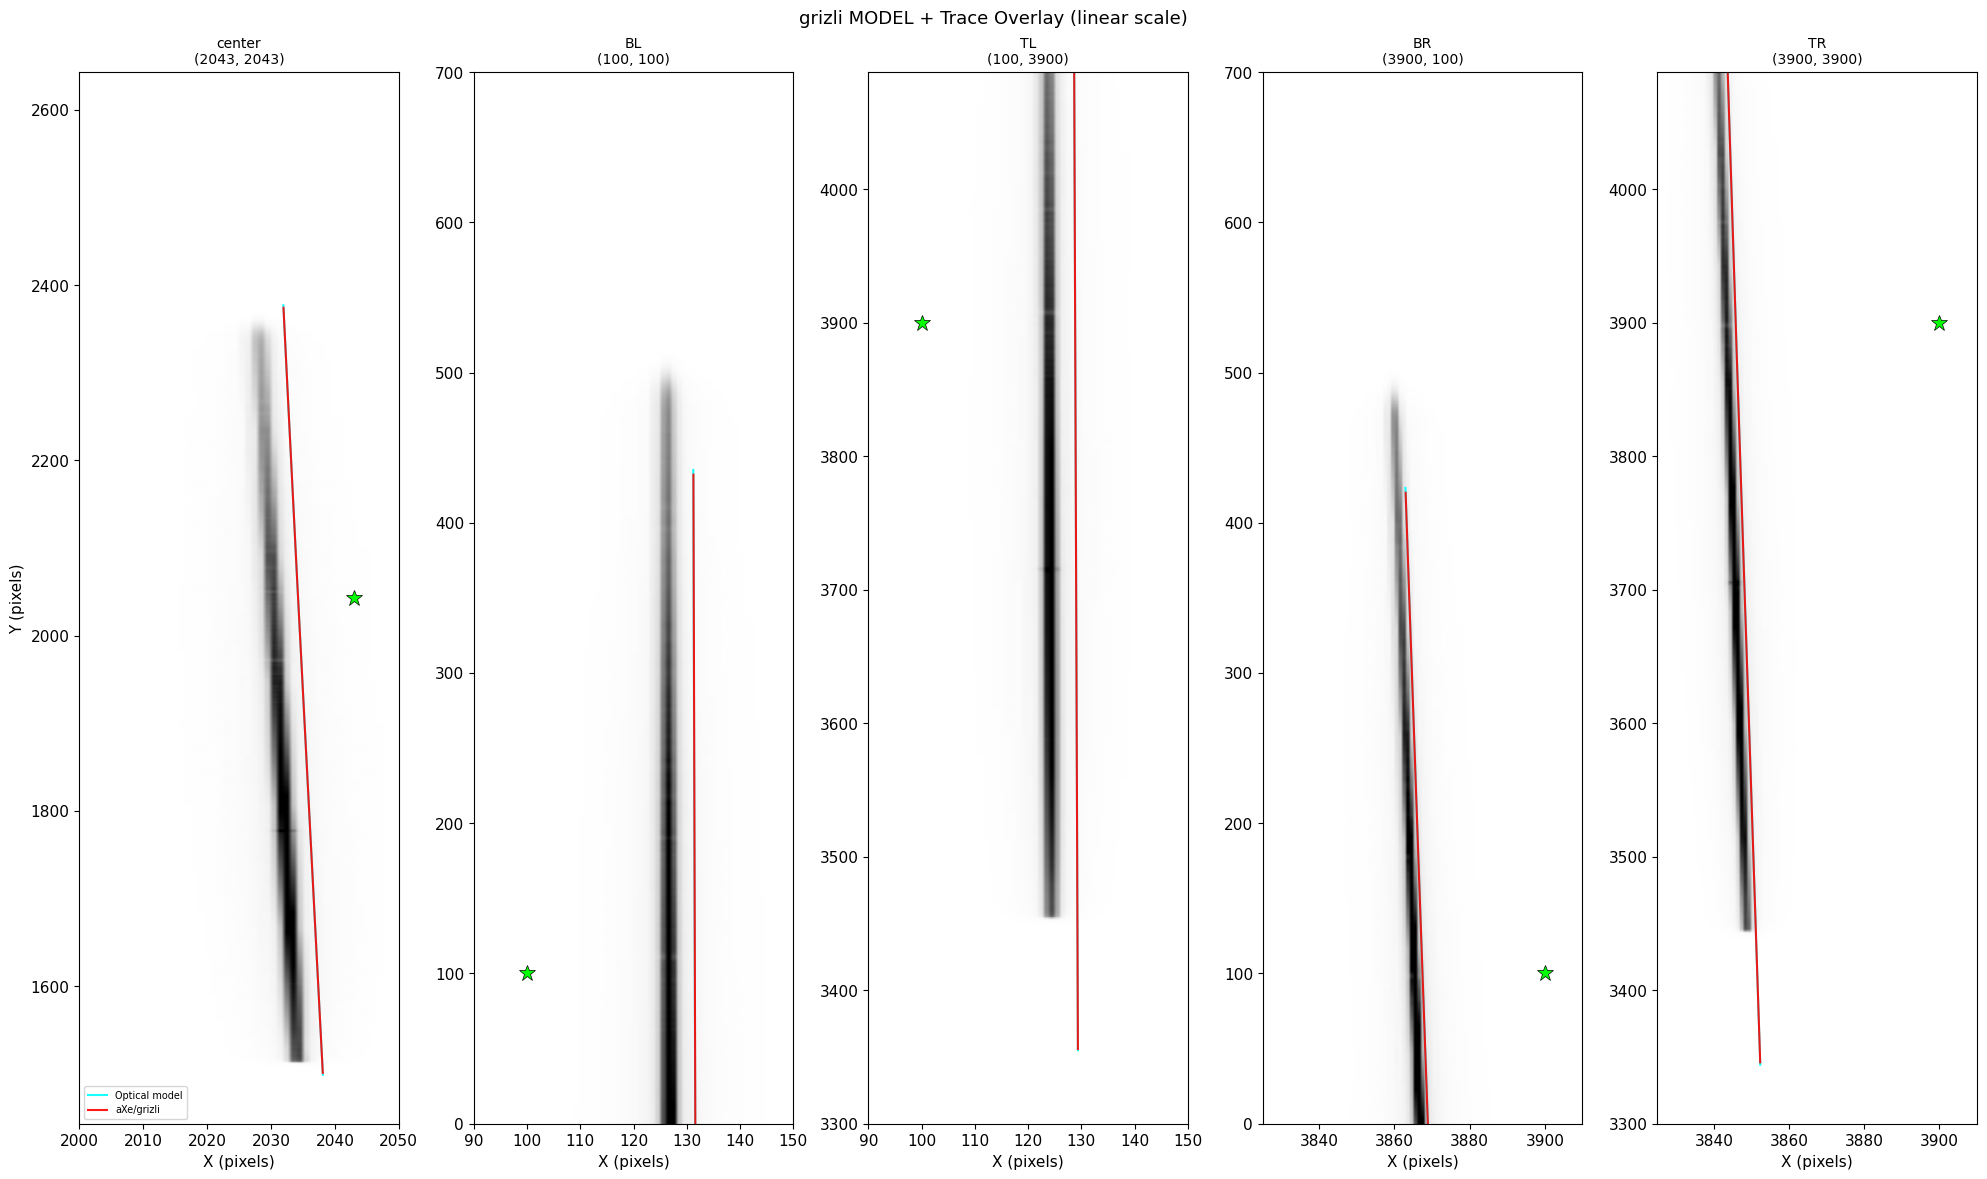

In [10]:
Y_HALF = 600  # 1200 pixels total in y

# Per-position x ranges
X_RANGES = {
    'center': (2000, 2050),
    'BL': (90, 150),
    'TL': (90, 150),
    'BR': (3825, 3910),
    'TR': (3825, 3910),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 12), sharey=False)

for ax, (label, tr) in zip(axes, traces.items()):
    xc, yc = tr['xc'], tr['yc']

    x_lo, x_hi = X_RANGES[label]
    y_lo = max(0, int(yc) - Y_HALF)
    y_hi = min(4088, int(yc) + Y_HALF)

    # Extract subimage
    subimg = grizli_model[y_lo:y_hi, x_lo:x_hi]
    extent = [x_lo, x_hi, y_lo, y_hi]

    # Linear scale clipped at local 99.5th percentile
    nz = subimg[subimg > 0]
    vmax_local = np.percentile(nz, 99.5) if len(nz) > 0 else 1.0

    ax.imshow(subimg, origin='lower', cmap='gray_r', vmin=0, vmax=vmax_local,
              extent=extent, aspect='auto')

    # Overlay traces
    ax.plot(tr['om_x'], tr['om_y'], '-', color='cyan', lw=1.5, alpha=0.9, label='Optical model')
    ax.plot(tr['axe_x'], tr['axe_y'], '-', color='red', lw=1.5, alpha=0.9, label='aXe/grizli')
    ax.plot(xc, yc, '*', color='lime', ms=12, mew=0.5, mec='k')

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    ax.set_title(f'{label}\n({xc:.0f}, {yc:.0f})', fontsize=10)
    ax.set_xlabel('X (pixels)')
    if ax == axes[0]:
        ax.set_ylabel('Y (pixels)')
        ax.legend(fontsize=7, loc='lower left')

plt.suptitle('grizli MODEL + Trace Overlay (linear scale)', fontsize=13)
plt.tight_layout()
plt.show()